In [1]:
import json
import os

import astropy.units as u
import cmasher
import gc_utils
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utilities as ut
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.stats import gaussian_kde, norm
from sklearn.mixture import GaussianMixture

# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

# Preamble

In [2]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
# sim_lst = ["m12i"]
sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"


bands_dict = {"JC": ["v"], "SDSS": ["sdss_g", "sdss_z"]}

scmap = plt.get_cmap("tab10")
colors = [scmap(i) for i in np.linspace(0, 1, len(sim_lst))]
sim_colors = {sim: colors[i] for i, sim in enumerate(sim_lst)}

snap = 600
min_mass = 1e4

sim_halt_path = "../data/sim_data/sim_halt_dict.json"

In [3]:
public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
timez0 = float(pub_data[pub_data["index"] == snap]["time_Gyr"].values[0])
pub_snaps = np.array(pub_data["index"])

all_data_fil = sim_dir + "/" + "m12i" + "/" + "m12i" + "_res7100/" + "snapshot_times.txt"
all_data = pd.read_table(all_data_fil, comment="#", header=None, sep=r"\s+")
all_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
all_times = np.array(all_data["time_Gyr"])
all_snaps = np.array(all_data["index"])

snap_times = {
    gc_utils.snapshot_name(s): float(pub_data.loc[pub_data["index"] == s, "time_Gyr"].values[0])
    for s in pub_snaps
}

sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

dat_dir = "../data/"
mw_gcs_fil = "mw_gcs/mw_gcs.csv"
mw_gcs = pd.read_csv(dat_dir + mw_gcs_fil)

mw_gcs_cols_fil = "mw_gcs/mw_gcs_colors_ref.csv"
mw_gcs_cols = pd.read_csv(dat_dir + mw_gcs_cols_fil)

mw_gc_class = "../data/mw_gcs/class_chen.txt"
mw_class = pd.read_csv(mw_gc_class, sep=r"\s+")

mw_class.loc[mw_class["Cluster"] == "ESO-SC06", "Cluster"] = "ESO_280-SC06"
mw_class.loc[mw_class["Cluster"] == "1636-283", "Cluster"] = "ESO_452-SC11"

mw_class = mw_class.rename(columns={"Cluster": "cluster_name"})

# Prepare Data

In [4]:
sim_dict = {}

# ------------------------------------------------
# precompute snapshot times once
# ------------------------------------------------
snap_times = {
    gc_utils.snapshot_name(s): float(pub_data.loc[pub_data["index"] == s, "time_Gyr"].values[0])
    for s in pub_snaps
}

timez0 = snap_times[gc_utils.snapshot_name(snap)]

for sim in sim_lst:
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    sim_dict[sim] = {}

    with h5py.File(ghost_file, "r") as ghost_data:
        for it_id, it_grp in ghost_data.items():
            src = it_grp["source"]

            # ---------------------------
            # read once
            # ---------------------------
            grpid = src["grpid"][()]
            amsk = grpid == 0

            logm_tfor = src["logm_tfor"][()]
            logm_tz0 = src["logm_tz0"][()]

            m_tfo = 10.0**logm_tfor
            m_tfo_ev = 0.55 * m_tfo  # stellar-evolution corrected mass

            m_tz0 = np.zeros_like(logm_tz0, dtype=float)
            msk = logm_tz0 != -1
            m_tz0[msk] = 10.0 ** logm_tz0[msk]

            tfor = src["tfor"][()]
            tdis = src["tdis"][()]
            tacc = src["tacc"][()]
            feh = src["feh"][()]
            gcids = src["gcid"][()]

            tdis = np.where(tdis == -1, np.inf, tdis)

            rz0 = np.linalg.norm(src["pxyz_snap600"][()], axis=1)

            # ---------------------------
            # vectorized ages
            # ---------------------------
            age = timez0 - tfor
            age_p = np.where(np.isfinite(tdis), tdis - tfor, age)

            t_tz0 = src["torb_600"][()]
            s_tz0 = src["s_flag"][()].astype(bool)
            sa_flag = src["sa_flag"][()].astype(bool)

            # ---------------------------
            # snapshot mass table
            #   + tfor (m_tfo_ev)
            #   + tdis (0)
            # ---------------------------
            n_gc = len(gcids)
            n_snap = len(pub_snaps)

            mass_arr = np.full((n_gc, n_snap + 2), np.nan)
            time_arr = np.full((n_gc, n_snap + 2), np.nan)

            # ---- formation point ----
            mass_arr[:, 0] = m_tfo_ev
            time_arr[:, 0] = tfor

            # ---- simulation snapshots ----
            for j, (snap_id, time) in enumerate(snap_times.items(), start=1):
                snp = it_grp["snapshots"][snap_id]
                snp_gcids = snp["gcid"][()]
                snp_mass = 10.0 ** snp["logm"][()]

                common, idx_snp, idx_src = np.intersect1d(snp_gcids, gcids, return_indices=True)

                mass_arr[idx_src, j] = snp_mass[idx_snp]
                time_arr[idx_src, j] = time

                # ---- disruption point (only if disrupted) ----
                has_disrupted = np.isfinite(tdis)

                mass_arr[has_disrupted, -1] = 0.0
                time_arr[has_disrupted, -1] = tdis[has_disrupted]

            # ---------------------------
            # final mass cut
            # ---------------------------
            m_tfo_msk = m_tfo >= min_mass

            sim_dict[sim][it_id] = {
                "gcid": gcids[m_tfo_msk],
                "feh": feh[m_tfo_msk],
                "tfor": tfor[m_tfo_msk],
                "tdis": tdis[m_tfo_msk],
                "tacc": tacc[m_tfo_msk],
                "age": age[m_tfo_msk],
                "age_p": age_p[m_tfo_msk],
                "rz0": rz0[m_tfo_msk],
                "t_tz0": t_tz0[m_tfo_msk],
                "s_tz0": s_tz0[m_tfo_msk],
                "sa_flag": sa_flag[m_tfo_msk],
                "acc": amsk[m_tfo_msk],
                # ---- masses ----
                "m_tfo": m_tfo[m_tfo_msk],
                "m_tfo_ev": m_tfo_ev[m_tfo_msk],
                "m_tz0": m_tz0[m_tfo_msk],
                # ---- time-resolved mass history ----
                "m_snp": mass_arr[m_tfo_msk],
                "t_snp": time_arr[m_tfo_msk],
            }

In [5]:
def build_mass_interpolators(dat):
    interps = []

    for m, t in zip(dat["m_snp"], dat["t_snp"]):
        msk = np.isfinite(m) & (m > 0)
        if np.sum(msk) < 2:
            interps.append(None)
            continue

        order = np.argsort(t[msk])
        ts = t[msk][order]
        ms = m[msk][order]

        interps.append(interp1d(ts, ms, kind="linear", bounds_error=False, fill_value=(ms[0], 0.0)))

    return interps


for sim in sim_lst:
    for it_id in sim_dict[sim]:
        sim_dict[sim][it_id]["mass_interp"] = build_mass_interpolators(sim_dict[sim][it_id])

In [6]:
# ------------------------------------------------------------------
# time grid
dt = 0.2
tims = np.arange(0.4, timez0, dt)
tims = np.append(tims, timez0)


def quant_age(age, dt=0.2):
    """Quantise age to SSP time grid to avoid float lookup issues."""
    return np.round(age / dt) * dt


# ------------------------------------------------------------------
for sim in sim_lst:
    print(f"[SIM] {sim}")

    for band_type in bands_dict.keys():
        # ---------- band info ----------
        band_names = bands_dict[band_type]
        n_band = len(band_names)
        bands_tag = "_".join(band_names)

        # ---------- load SSP cache ----------
        cache_dir = f"../data/ssp_caches/{sim}"
        cache_path = f"{cache_dir}/ssp_{band_type}_{bands_tag}.npz"

        cache = np.load(cache_path)
        ssp_mag = cache["ssp_mag"]  # shape: (n_ssp, n_band)
        ssp_mass = cache["ssp_mass"]  # shape: (n_ssp,)
        unique_ssps = cache["unique_ssps"]  # shape: (n_ssp, 2) [age, feh]

        # ---------- build SSP lookup ----------
        ssp_lookup = {(quant_age(unique_ssps[i, 0]), unique_ssps[i, 1]): i for i in range(len(unique_ssps))}

        # ---------- loop over iterations ----------
        for it_id, dat in sim_dict[sim].items():
            if it_id == "ssp_times":
                continue

            print(f"    {band_type}  -  {it_id}")

            gcids = dat["gcid"]
            tfor = dat["tfor"]
            feh = dat["feh"]
            tdis = dat["tdis"]
            tacc = dat["tacc"]
            mass_interp = dat["mass_interp"]

            n_gc = len(gcids)
            n_t = len(tims)

            # ---------- output magnitude cube ----------
            mag_cube = np.full((n_gc, n_t, n_band), np.nan, dtype=float)

            # ---------- time evolution ----------
            for ti, t in enumerate(tims):
                alive = (tfor <= t) & (t < tdis) & (tacc <= t)

                for i in np.where(alive)[0]:
                    fmass = mass_interp[i]
                    if fmass is None:
                        continue

                    m_now = float(fmass(t))
                    if m_now <= 0:
                        continue

                    age = t - tfor[i]
                    if age <= 0:
                        continue

                    key = (quant_age(age), feh[i])
                    ssp_idx = ssp_lookup.get(key)

                    if ssp_idx is None:
                        continue

                    mag_cube[i, ti, :] = ssp_mag[ssp_idx] - 2.5 * np.log10(m_now / ssp_mass[ssp_idx])

            # ---------- store per-band results ----------
            for b, band_name in enumerate(band_names):
                dat[band_name] = mag_cube[:, :, b]

[SIM] m12b
    JC  -  it000
    JC  -  it001
    JC  -  it002
    JC  -  it003
    JC  -  it004
    JC  -  it005
    JC  -  it006
    JC  -  it007
    JC  -  it008
    JC  -  it009
    JC  -  it010
    JC  -  it011
    JC  -  it012
    JC  -  it013
    JC  -  it014
    JC  -  it015
    JC  -  it016
    JC  -  it017
    JC  -  it018
    JC  -  it019
    JC  -  it020
    JC  -  it021
    JC  -  it022
    JC  -  it023
    JC  -  it024
    JC  -  it025
    JC  -  it026
    JC  -  it027
    JC  -  it028
    JC  -  it029
    JC  -  it030
    JC  -  it031
    JC  -  it032
    JC  -  it033
    JC  -  it034
    JC  -  it035
    JC  -  it036
    JC  -  it037
    JC  -  it038
    JC  -  it039
    JC  -  it040
    JC  -  it041
    JC  -  it042
    JC  -  it043
    JC  -  it044
    JC  -  it045
    JC  -  it046
    JC  -  it047
    JC  -  it048
    JC  -  it049
    JC  -  it050
    JC  -  it051
    JC  -  it052
    JC  -  it053
    JC  -  it054
    JC  -  it055
    JC  -  it056
    JC  -  it057
   

In [7]:
def halo_mvir_history(halt, halo_tid0, slst):
    """Return Mvir(t) for a halo tracked over snapshots."""
    mvir = []
    for snp in slst:
        tid = gc_utils.get_halo_prog_at_snap(halt, halo_tid0, snp)
        idx = np.where(halt["tid"] == tid)[0][0]
        mvir.append(halt["mass.vir"][idx])
    return np.asarray(mvir)


def gc_counts_and_mass(tim, select, t_snp, m_snp):
    masses = []
    for i in np.where(select)[0]:
        x = t_snp[i]
        y = m_snp[i]
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() >= 2:
            masses.append(np.interp(tim, x[mask], y[mask]))
    return np.sum(select), np.nansum(masses)


def get_gc_prop(sim, sim_dict, halt, host_tid, tims):
    """
    Compute GC count and mass evolution averaged over iterations,
    plus pre-accretion group properties and halo Mvir histories.
    """

    # --- shared time grid ---
    # tlst_start = np.arange(2, 14, 0.5)
    idxs = np.abs(all_times[:, None] - tims).argmin(axis=0)
    tlst = all_times[idxs]
    slst = all_snaps[idxs]

    # --- host halo virial-mass history ---
    host_mvir = halo_mvir_history(halt, host_tid, slst)

    it_ids = list(sim_dict[sim].keys())

    # ==========================================================================
    # ALL GCs (in MW)
    # ==========================================================================
    gccnts_all = []
    gcmass_all = []

    for it_id in it_ids:
        dat = sim_dict[sim][it_id]

        tfor = dat["tfor"]
        tdis = dat["tdis"].copy()
        tdis[tdis == -1] = np.inf
        tacc = dat["tacc"]

        t_snp = dat["t_snp"]
        m_snp = dat["m_snp"]

        cnt = np.zeros(len(tlst))
        mas = np.zeros(len(tlst))

        for k, tim in enumerate(tlst):
            alive = (tfor <= tim) & (tim < tdis)
            inmw = tacc <= tim
            select = alive & inmw

            cnt[k], mas[k] = gc_counts_and_mass(tim, select, t_snp, m_snp)

        gccnts_all.append(cnt)
        gcmass_all.append(mas)

    gccnts_all = np.asarray(gccnts_all)
    gcmass_all = np.asarray(gcmass_all)

    # averages over iterations
    gccnts_mean = gccnts_all.mean(axis=0)
    gccnts_std = gccnts_all.std(axis=0)
    gcmass_mean = gcmass_all.mean(axis=0)
    gcmass_std = gcmass_all.std(axis=0)

    # ==========================================================================
    # OUTPUT
    # ==========================================================================
    return {
        "time": tlst,
        "mvir": host_mvir,
        "cnt_avg": gccnts_mean,
        "cnt_std": gccnts_std,
        "mas_avg": gcmass_mean,
        "mas_std": gcmass_std,
    }


def to_json_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [to_json_serializable(v) for v in obj]
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    else:
        return obj

In [8]:
# --------------------------------------------------
# Load or compute
# --------------------------------------------------
if os.path.exists(sim_halt_path):
    print("Loading existing sim_halt_dict JSON...")
    with open(sim_halt_path, "r", encoding="utf-8") as f:
        sim_halt_dict = json.load(f)

else:
    print("JSON not found — computing sim_halt_dict...")
    sim_halt_dict = {sim: None for sim in sim_lst}

    for sim in sim_lst:
        print(sim)
        halt = gc_utils.get_halo_tree(sim, sim_dir)
        host_tid = sim_data[sim]["halo"]

        gc_prop_dict = get_gc_prop(sim, sim_dict, halt, host_tid, tims)
        sim_halt_dict[sim] = gc_prop_dict

        del halt

    # Convert NumPy objects → JSON-safe
    sim_halt_dict_json = to_json_serializable(sim_halt_dict)

    # Save
    with open(sim_halt_path, "w", encoding="utf-8") as f:
        json.dump(sim_halt_dict_json, f, indent=4)

    print("Saved sim_halt_dict JSON.")

Loading existing sim_halt_dict JSON...


# Get Plotting Data

In [9]:
# Magnitude Histograms


def gaussian_fitting(all_mags, bins, K_test=[1, 2, 3, 4], BIC_THRESHOLD=6.0):

    # mag_pool = np.concatenate(all_mags).reshape(-1, 1)

    if isinstance(all_mags, (list, tuple)):
        mags_list = [np.asarray(m).ravel() for m in all_mags]
    else:
        mags_list = [np.asarray(all_mags).ravel()]

    # Pool magnitudes for fitting
    mag_pool = np.concatenate(mags_list).reshape(-1, 1)

    # -------------------------------
    # 1. BIC-BASED STRUCTURE TEST
    # -------------------------------

    bics = {}
    gmms = {}

    for K in K_test:
        gmm = GaussianMixture(
            n_components=K,
            covariance_type="full",
            n_init=20,
            random_state=42,
        )
        gmm.fit(mag_pool)
        bics[K] = gmm.bic(mag_pool)
        gmms[K] = gmm

    # -------------------------------
    # 2. CLASSIFY STRUCTURE (GENERAL)
    # -------------------------------

    K_sorted = sorted(bics.keys())
    Kbest = K_sorted[0]

    for K_prev, K_next in zip(K_sorted[:-1], K_sorted[1:]):
        delta_bic = bics[K_prev] - bics[K_next]
        if delta_bic >= BIC_THRESHOLD:
            Kbest = K_next
        else:
            break

    # Human-readable label
    if Kbest == 1:
        structure = "unimodal"
    elif Kbest == 2:
        structure = "bimodal"
    elif Kbest == 3:
        structure = "trimodal"
    else:
        structure = f"{Kbest}-modal"

    print(f"\nGC colour population is classified as: {structure.upper()}")

    # -------------------------------
    # 3. BUILD BEST-FIT MODEL CURVE
    # -------------------------------

    gmm = gmms[Kbest]
    weights = gmm.weights_
    means = gmm.means_.flatten()
    sigmas = np.sqrt(gmm.covariances_.flatten())

    x_plot = np.linspace(bins.min(), bins.max(), 1000)

    pdf_total = np.zeros_like(x_plot)
    pdf_components = []

    for k in range(Kbest):
        pdf_k = weights[k] * norm.pdf(x_plot, means[k], sigmas[k])
        pdf_components.append(pdf_k)
        pdf_total += pdf_k

    bin_width = bins[1] - bins[0]
    # mean_ngc = np.mean([len(m) for m in all_mags])
    mean_ngc = np.mean([len(m) for m in mags_list])
    # model_counts = pdf_total * bin_width * mean_ngc

    fit_dict = {
        "x_plot": x_plot,
        "pdf_total": pdf_total,
        "pdf_components": pdf_components,
        "bin_width": bin_width,
        "mean_ngc": mean_ngc,
        "Kbest": Kbest,
    }

    return fit_dict


def mags_hist(
    ax,
    sim,
    sim_dict,
    tim,
    tims,
    bins,
    bands=["v"],
    origin=False,
    gauss_fit=False,
    plt_text=False,
    ymax=None,
    K_test=[1, 2, 3, 4],
    BIC_THRESHOLD=6.0,
    cmap="cmr.guppy",
):
    ax.clear()

    if origin & gauss_fit:
        raise RuntimeError("Can't do origin and gauss_fit at the same time, choose one")

    if len(bands) == 1:
        colors = False
        print(f"Plotting {bands[0]} magnitudes")
    elif len(bands) == 2:
        colors = True
        print(f"Plotting {bands[0]}-{bands[1]} color")
    else:
        raise RuntimeError("Can't do origin and gauss_fit at the same time, choose one")

    hist_dict = {"sum": None, "insum": None, "exsum": None, "n": 0}

    # tims = sim_dict["times"]
    tidx = np.where(tims == tim)[0][0]

    all_mags = []
    for it_id in sim_dict[sim].keys():
        insitu_msk = sim_dict[sim][it_id]["acc"]
        taccs = sim_dict[sim][it_id]["tacc"]
        tacc_msk = tim > taccs

        if colors:
            mag0 = sim_dict[sim][it_id][bands[0]][:, tidx]
            mag1 = sim_dict[sim][it_id][bands[1]][:, tidx]
            mags_hld = mag0 - mag1
        else:
            mags_hld = sim_dict[sim][it_id][bands[0]][:, tidx]

        fin_msk = np.isfinite(mags_hld)

        mags = mags_hld[fin_msk & tacc_msk]
        mags_in = mags_hld[fin_msk & tacc_msk & insitu_msk]
        mags_ex = mags_hld[fin_msk & tacc_msk & ~insitu_msk]

        all_mags.append(mags)

        hssp, _ = np.histogram(mags, bins=bins)
        hssp_in, _ = np.histogram(mags_in, bins=bins)
        hssp_ex, _ = np.histogram(mags_ex, bins=bins)

        if hist_dict["sum"] is None:
            hist_dict["sum"] = hssp.astype(float)
            hist_dict["insum"] = hssp_in.astype(float)
            hist_dict["exsum"] = hssp_ex.astype(float)
        else:
            hist_dict["sum"] += hssp
            hist_dict["insum"] += hssp_in
            hist_dict["exsum"] += hssp_ex

        hist_dict["n"] += 1

    binsum = hist_dict["sum"] / hist_dict["n"]
    binsum_in = hist_dict["insum"] / hist_dict["n"]
    binsum_ex = hist_dict["exsum"] / hist_dict["n"]

    if origin:
        ax.step(bins[:-1], binsum_in, where="post", color="r", label="in-situ")
        ax.step(bins[:-1], binsum_ex, where="post", color="b", label="ex-situ")

    elif gauss_fit:
        fd = gaussian_fitting(all_mags, bins, K_test, BIC_THRESHOLD)
        cmap = mpl.colormaps.get_cmap(cmap).resampled(fd["Kbest"])

        model_counts = fd["pdf_total"] * fd["bin_width"] * fd["mean_ngc"]

        ax.plot(
            fd["x_plot"],
            model_counts,
            color="k",
            linewidth=1,
        )

        for k, pdf_k in enumerate(fd["pdf_components"]):
            ax.plot(
                fd["x_plot"],
                pdf_k * fd["bin_width"] * fd["mean_ngc"],
                linestyle="--",
                linewidth=1.5,
                color=cmap(k),
            )

    ax.step(bins[:-1], binsum, where="post", color="k", linewidth=1, label="all")

    ax.set_xlim(bins[0], bins[-1])

    if ymax is None:
        ymax = np.ceil(np.max(binsum) / 10) * 12
    ax.set_ylim(0, ymax)

    if plt_text:
        if tim > 13.78:
            z = 0
        else:
            z = z_at_value(cosmo.age, tim * u.Gyr)

        text = (
            sim + "\n" + "t = " + str(np.round(tim, 2)) + " Gyr" + "\n" + "z = " + str(np.round(float(z), 2))
        )

        ax.text(
            0.02,
            0.92,
            text,
            transform=ax.transAxes,
            color="k",
            ha="left",
            va="center",
            bbox=dict(
                facecolor="white",
                edgecolor="white",
            ),
        )

        ax.legend()

    ax.set_ylabel("GC Count")


def plot_mw_mags_hist(
    ax,
    mw_gcs,
    mw_gcs_cols,
    mw_class,
    bins,
    plot_type="mag",
    origin=False,
    gauss_fit=False,
    K_test=[1, 2, 3, 4],
    BIC_THRESHOLD=6.0,
    cmap="cmr.eclipse",
    plt_text=False,
):

    if origin & gauss_fit:
        raise RuntimeError("Can't do origin and gauss_fit at the same time, choose one")

    if plot_type not in ("mag", "col"):
        raise RuntimeError("plot_type must be 'mag' or 'col'")

    # Ensure cluster_name is string everywhere
    for df in (mw_class, mw_gcs, mw_gcs_cols):
        df["cluster_name"] = df["cluster_name"].astype(str)

    # Merge Origin from mw_class with V_abs from mw_gcs
    df = mw_class.merge(
        mw_gcs[["cluster_name", "V_abs"]],
        on="cluster_name",
        how="inner",
    )

    # Merge colour columns from mw_gcs_cols
    df = df.merge(
        mw_gcs_cols[
            [
                "cluster_name",
                "JC_V-SDSS_g",
                "JC_V-SDSS_z",
            ]
        ],
        on="cluster_name",
        how="inner",
    )

    mw_v = df["V_abs"]
    mw_g = mw_v - df["JC_V-SDSS_g"]
    mw_z = mw_v - df["JC_V-SDSS_z"]
    inmsk = df["Origin"] == "in-situ"

    if plot_type == "mag":
        mag = mw_v
        xlab = r"M$_{V}$"
    elif plot_type == "col":
        mag = mw_g - mw_z
        xlab = r"(g-z)$_{0}$"

    if origin:
        ax.hist(mag[inmsk], bins=bins, color="r", label="in-situ", histtype="step", lw=1.5)
        ax.hist(mag[~inmsk], bins=bins, color="b", label="ex-situ", histtype="step", lw=1.5)

    elif gauss_fit:
        fd = gaussian_fitting(mag, bins, K_test, BIC_THRESHOLD)
        cmap = mpl.colormaps.get_cmap(cmap).resampled(fd["Kbest"])

        model_counts = fd["pdf_total"] * fd["bin_width"] * fd["mean_ngc"]

        ax.plot(
            fd["x_plot"],
            model_counts,
            color="k",
            linewidth=1,
        )

        for k, pdf_k in enumerate(fd["pdf_components"]):
            ax.plot(
                fd["x_plot"],
                pdf_k * fd["bin_width"] * fd["mean_ngc"],
                linestyle="--",
                linewidth=1.5,
                color=cmap(k),
            )

    ax.hist(mag, bins=bins, color="k", histtype="step", lw=1, label="all")

    if plt_text:
        ax.legend()

        text = "Milky Way" + "\n" + "t = " + str(13.80) + " Gyr" + "\n" + "z = " + str(0)

        ax.text(
            0.02,
            0.92,
            text,
            transform=ax.transAxes,
            color="k",
            ha="left",
            va="center",
            bbox=dict(
                facecolor="white",
                edgecolor="white",
            ),
        )

    ax.set_xlim(bins[0], bins[-1])
    ax.set_ylim(0, 50)

    ax.set_xlabel(xlab)
    ax.set_ylabel("GC Count")


In [10]:
# Survival Boundaries


def plot_cont_bounding(ax, sim, tcut, in_msk=True, cont_level=0.95, plt_text=False):
    ax.clear()

    ############################################################
    logx_grid = np.linspace(3, 7.2, 200)
    logy_grid = np.linspace(0, 4, 200)
    XX, YY = np.meshgrid(logx_grid, logy_grid)
    grid_positions = np.vstack([XX.ravel(), YY.ravel()])
    ############################################################

    ############################################################
    Z0_list = []
    Z1_list = []

    print(f"{sim} - {tcut} - {in_msk}")
    for it_id in sim_dict[sim].keys():
        # for it_id in ["it001"]:
        # print(f"{sim} - {it_id} - {in_msk}")
        acc = sim_dict[sim][it_id]["acc"] == in_msk
        mfor = sim_dict[sim][it_id]["m_tfo"]
        pz0 = sim_dict[sim][it_id]["t_tz0"]
        sa_msk = sim_dict[sim][it_id]["sa_flag"][()]  # only consider GCs that were alive in the MW
        tacc = sim_dict[sim][it_id]["tacc"]
        tdis = sim_dict[sim][it_id]["tdis"].copy()
        tfor = sim_dict[sim][it_id]["tfor"]
        tdis[tdis == -1] = np.inf

        tfor_msk = tfor <= tcut
        # tfor_msk = tfor <= np.inf
        tdis_msk = tdis <= tcut
        tacc_msk = tacc <= tcut

        x0 = mfor[tfor_msk & tacc_msk & tdis_msk & acc & sa_msk]
        y0 = pz0[tfor_msk & tacc_msk & tdis_msk & acc & sa_msk]
        x1 = mfor[tfor_msk & tacc_msk & ~tdis_msk & acc & sa_msk]
        y1 = pz0[tfor_msk & tacc_msk & ~tdis_msk & acc & sa_msk]

        log_x0 = np.log10(x0)
        log_y0 = np.log10(y0)
        log_x1 = np.log10(x1)
        log_y1 = np.log10(y1)

        if len(log_x0) > 5:
            kde0 = gaussian_kde(np.vstack([log_x0, log_y0]))
            Z0 = kde0(grid_positions).reshape(XX.shape)
            Z0 /= Z0.sum()  # equal weight per iteration
            Z0_list.append(Z0)

        if len(log_x1) > 5:
            kde1 = gaussian_kde(np.vstack([log_x1, log_y1]))
            Z1 = kde1(grid_positions).reshape(XX.shape)
            Z1 /= Z1.sum()  # equal weight per iteration
            Z1_list.append(Z1)

    if in_msk:
        col = "r"
    else:
        col = "b"

    if len(Z0_list) > 0:
        Z0_avg = np.mean(Z0_list, axis=0)
        Z0_avg[XX <= 4] = 0
        Z0f = Z0_avg.ravel()
        idx = np.argsort(Z0f)[::-1]
        Z0s = Z0f[idx]
        Z0_cdf = np.cumsum(Z0s)
        Z0_cdf /= Z0_cdf[-1]
        level = Z0s[np.searchsorted(Z0_cdf, cont_level)]
        ax.contour(10**XX, 10**YY, Z0_avg, levels=[level], colors="grey", linewidths=2)

    if len(Z1_list) > 0:
        Z1_avg = np.mean(Z1_list, axis=0)
        Z1_avg[XX <= 4] = 0
        Z1f = Z1_avg.ravel()
        idx = np.argsort(Z1f)[::-1]
        Z1s = Z1f[idx]
        Z1_cdf = np.cumsum(Z1s)
        Z1_cdf /= Z1_cdf[-1]
        level = Z1s[np.searchsorted(Z1_cdf, cont_level)]
        ax.contour(10**XX, 10**YY, Z1_avg, levels=[level], colors=col, linewidths=2)

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlim(10**3.9, 10**7)
    ax.set_ylim(10**0.3, 10**4.1)

    ax.set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")
    ax.set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

    if plt_text:
        if tcut > 13.78:
            z = 0
        else:
            z = z_at_value(cosmo.age, tcut * u.Gyr)

        text = (
            sim + "\n" + "t = " + str(np.round(tcut, 2)) + " Gyr" + "\n" + "z = " + str(np.round(float(z), 2))
        )

        ax.text(
            0.02,
            0.92,
            text,
            transform=ax.transAxes,
            color="k",
            ha="left",
            va="center",
            bbox=dict(
                facecolor="white",
                edgecolor="white",
            ),
        )

        surv = Line2D([0], [0], color=col, linewidth=2, label="Surviving Population")
        disr = Line2D([0], [0], color="grey", linewidth=2, label="Disrupted Population")
        ax.legend(handles=[surv, disr], frameon=False)


In [11]:
# in vs ex ratios


def plot_ratios(ax, sim, sim_dict, tim, tims, mw_class, include_mw=True):
    ts = tims[tims <= tim]

    incnt = []
    excnt = []
    total = []
    for it_id in sim_dict[sim].keys():
        dat = sim_dict[sim][it_id]

        tfor = dat["tfor"]
        tdis = dat["tdis"].copy()
        tdis[tdis == -1] = np.inf
        tacc = dat["tacc"]

        incnt_i = []
        excnt_i = []
        total_i = []
        for t in ts:
            alive = (tfor <= t) & (t < tdis)
            inmw = tacc <= t
            insitu = dat["acc"]

            incnt_i.append(np.sum(alive & inmw & insitu))
            excnt_i.append(np.sum(alive & inmw & ~insitu))
            total_i.append(np.sum(alive & inmw))

        incnt.append(np.asarray(incnt_i))
        excnt.append(np.asarray(excnt_i))
        total.append(np.asarray(total_i))

    inrat = []
    exrat = []
    # for i, _ in enumerate(incnt):
    #     inrat.append(incnt[i] / total[i])
    #     exrat.append(excnt[i] / total[i])

    for i in range(len(incnt)):
        with np.errstate(divide="ignore", invalid="ignore"):
            inr = np.where(total[i] > 0, incnt[i] / total[i], np.nan)
            exr = np.where(total[i] > 0, excnt[i] / total[i], np.nan)

        inrat.append(inr)
        exrat.append(exr)

    inrat_avg = np.mean(inrat, axis=0)
    exrat_avg = np.mean(exrat, axis=0)

    ax.plot(ts, inrat_avg, c="r", label="in-situ")
    ax.scatter(ts[-1], inrat_avg[-1], c="r", s=50)

    ax.plot(ts, exrat_avg, c="b", label="ex-situ")
    ax.scatter(ts[-1], exrat_avg[-1], c="b", s=50)

    ax.set_ylabel("Fraction of Total Clusters")
    ax.set_xlabel("Time (Gyr)")

    ax.set_xlim(0, 14.5)
    ax.set_ylim(0, 1)

    if include_mw:
        unq_class, cnts_class = np.unique(mw_class["Origin"], return_counts=True)

        inmsk = unq_class == "in-situ"

        in_sum = np.sum(cnts_class[inmsk])
        ex_sum = np.sum(cnts_class[~inmsk])

        ax.scatter(13.78, in_sum / (in_sum + ex_sum), marker="*", c="r", s=80)
        ax.scatter(13.78, ex_sum / (in_sum + ex_sum), marker="*", c="b", s=80)

        mw_handle = Line2D(
            [0], [0], marker="*", color="grey", linestyle="None", markersize=7, label="Milky Way"
        )

        handles, _ = ax.get_legend_handles_labels()
        handles.append(mw_handle)

    #     ax.legend(handles=handles, loc="lower right")

    # else:
    #     ax.legend(loc="lower right")

In [12]:
# scaling plots


def plot_gc_cnt(ax, sim, tim, sim_halt_dict, sim_colors, mw_gcs, plt_to=False, smoothing=False, labels=True):
    gc_prop_dict = sim_halt_dict[sim]

    # Convert JSON-loaded lists → NumPy arrays
    tim_lst = np.asarray(gc_prop_dict["time"], dtype=float)
    mvirs_all = np.asarray(gc_prop_dict["mvir"], dtype=float)
    gccnts_all = np.asarray(gc_prop_dict["cnt_avg"], dtype=float)

    tmsk = tim_lst <= tim

    mvirs = mvirs_all[tmsk]
    gccnts_mean = gccnts_all[tmsk]

    # SMOOTHING ########################################

    mask = np.isfinite(mvirs) & np.isfinite(gccnts_mean) & (gccnts_mean > 0) & (mvirs > 0)

    logM = np.log10(mvirs[mask])
    logNgc = np.log10(gccnts_mean[mask])
    time_v = tim_lst[tmsk][mask]

    order = np.argsort(logM)
    logM, logNgc, time_v = logM[order], logNgc[order], time_v[order]

    logM_fine = np.linspace(logM.min(), logM.max(), 300)

    fNgc = interp1d(logM, logNgc, kind="linear", fill_value="extrapolate")
    ftime = interp1d(logM, time_v, kind="linear", fill_value=np.nan)

    logNgc_fine = fNgc(logM_fine)
    logNgc_smooth = gaussian_filter1d(logNgc_fine, sigma=1)

    # Convert back to linear
    M_smooth = 10**logM_fine
    Ngc_smooth = 10**logNgc_smooth

    # M_smooth = np.append(M_smooth, mvirs[-1])
    # Ngc_smooth = np.append(Ngc_smooth, gccnts_mean[-1])

    ####################################################

    if labels:
        label = sim
    else:
        label = None

    if smoothing:
        ax.plot(M_smooth, Ngc_smooth, c=sim_colors[sim], lw=2, label=label)
        if len(mvirs) > 0:
            ax.scatter(M_smooth[-1], Ngc_smooth[-1], color=sim_colors[sim], s=40)
    else:
        ax.plot(mvirs, gccnts_mean, c=sim_colors[sim], lw=2, label=label)
        if len(mvirs) > 0:
            ax.scatter(mvirs[-1], gccnts_mean[-1], color=sim_colors[sim], s=40)

    logx = np.arange(5, 16.5, 0.5)
    x = 10**logx

    logy = -9.58 + 0.99 * logx
    y = 10**logy

    # Burkert & Forbes 2020
    ax.plot(x, y, c="k", zorder=0)

    ax.set_xlim(10**10, 10**13)
    ax.set_ylim(10**0, 10**5)

    # Milky Way
    mw_vir = 1.3e12
    ax.scatter(mw_vir, len(mw_gcs), marker="*", c="magenta", s=80)

    ax.set_xscale("log")
    ax.set_yscale("log")

    if plt_to:
        idx = np.nanargmax(logNgc_smooth)
        ax.axvline(10.0 ** logM_fine[idx], c=sim_colors[sim], ls="dashed", zorder=0, lw=0.5)
        print(sim, "- GC Count Turn-off -", np.round(ftime(logM_fine[idx]), 2))


def plot_gc_mas(ax, sim, tim, sim_halt_dict, sim_colors, mw_gcs, plt_to=False, smoothing=False, labels=True):
    gc_prop_dict = sim_halt_dict[sim]

    # Convert JSON-loaded lists → NumPy arrays
    tim_lst = np.asarray(gc_prop_dict["time"])
    mvirs_all = np.asarray(gc_prop_dict["mvir"])
    gcmas_all = np.asarray(gc_prop_dict["mas_avg"])

    tmsk = tim_lst <= tim

    mvirs = mvirs_all[tmsk]
    gcmas_mean = gcmas_all[tmsk]

    # SMOOTHING ########################################

    mask = np.isfinite(mvirs) & np.isfinite(gcmas_mean) & (gcmas_mean > 0) & (mvirs > 0)

    logM = np.log10(mvirs[mask])
    logMgc = np.log10(gcmas_mean[mask])
    time_v = tim_lst[tmsk][mask]

    order = np.argsort(logM)
    logM, logMgc, time_v = logM[order], logMgc[order], time_v[order]

    logM_fine = np.linspace(logM.min(), logM.max(), 300)

    fMgc = interp1d(logM, logMgc, kind="linear", fill_value="extrapolate")
    ftime = interp1d(logM, time_v, kind="linear", fill_value=np.nan)

    logMgc_fine = fMgc(logM_fine)
    logMgc_smooth = gaussian_filter1d(logMgc_fine, sigma=1)

    # Convert back to linear
    M_smooth = 10**logM_fine
    Mgc_smooth = 10**logMgc_smooth

    # M_smooth = np.append(M_smooth, mvirs[-1])
    # Mgc_smooth = np.append(Mgc_smooth, gcmas_mean[-1])

    ####################################################

    if labels:
        label = sim
    else:
        label = None

    if smoothing:
        ax.plot(M_smooth, Mgc_smooth, c=sim_colors[sim], lw=2, label=label)
        if len(mvirs) > 0:
            ax.scatter(M_smooth[-1], Mgc_smooth[-1], color=sim_colors[sim], s=40)
    else:
        ax.plot(mvirs, gcmas_mean, c=sim_colors[sim], lw=2, label=label)
        if len(mvirs) > 0:
            ax.scatter(mvirs[-1], gcmas_mean[-1], color=sim_colors[sim], s=40)

    logx = np.arange(5, 16.5, 0.5)
    x = 10**logx

    x12 = x * 1e-12
    logx12 = np.log10(x12)
    logy = 7.45 + 0.93 * logx12
    y = 10**logy

    # Chen & Gnedin 2023
    ax.plot(x, y, c="k", zorder=0)

    ax.set_xlim(1e10, 1e13)
    ax.set_ylim(1e5, 1e10)

    # Milky Way
    mw_vir = 1.3e12
    ax.scatter(mw_vir, np.sum(mw_gcs["mass"]), marker="*", c="magenta", s=80)

    ax.set_xscale("log")
    ax.set_yscale("log")

    if plt_to:
        idx = np.nanargmax(logMgc_smooth)
        ax.axvline(10.0 ** logM_fine[idx], c=sim_colors[sim], ls="dashed", zorder=0, lw=0.5)
        print(sim, "- GC Mass Turn-off -", np.round(ftime(logM_fine[idx]), 2))

In [13]:
def gc_masses_at_time(tim, select, t_snp, m_snp):
    """
    Return array of GC masses at time tim.
    """
    masses = []

    for i in np.where(select)[0]:
        x = t_snp[i]
        y = m_snp[i]

        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() >= 2:
            masses.append(np.interp(tim, x[mask], y[mask]))

    return np.asarray(masses)


def mass_histogram(ax, sim, sim_dict, tim, density=False):
    ax.clear()
    bins = 10 ** np.linspace(2, 7.1, 52)

    hist_dict = {"insum": None, "exsum": None, "n": 0}

    for it_id in sim_dict[sim].keys():
        dat = sim_dict[sim][it_id]

        tfor = dat["tfor"]
        tdis = dat["tdis"].copy()
        tdis[tdis == -1] = np.inf
        tacc = dat["tacc"]

        t_snp = dat["t_snp"]
        m_snp = dat["m_snp"]

        alive = (tfor <= tim) & (tim < tdis)
        inmw = tacc <= tim
        insitu = dat["acc"]

        in_select = alive & inmw & insitu
        ex_select = alive & inmw & ~insitu

        in_masses = gc_masses_at_time(tim, in_select, t_snp, m_snp)
        ex_masses = gc_masses_at_time(tim, ex_select, t_snp, m_snp)

        hin, _ = np.histogram(in_masses, bins=bins)
        hex, _ = np.histogram(ex_masses, bins=bins)

        if hist_dict["insum"] is None:
            hist_dict["insum"] = hin.astype(float)
            hist_dict["exsum"] = hex.astype(float)
        else:
            hist_dict["insum"] += hin
            hist_dict["exsum"] += hex

        hist_dict["n"] += 1

    # bin_centers = 0.5 * (bins[:-1] + bins[1:])
    widths = bins[1:] - bins[:-1]

    insum = hist_dict["insum"] / hist_dict["n"]
    exsum = hist_dict["exsum"] / hist_dict["n"]

    if density:
        insum = insum / np.sum(insum * widths)
        exsum = exsum / np.sum(exsum * widths)

    ax.step(bins[:-1], insum, where="post", color="r", label="in-situ")
    ax.fill_between(bins[:-1], insum, step="post", alpha=0.5, color="r")

    ax.step(bins[:-1], exsum, where="post", color="b", label="ex-situ")
    ax.fill_between(bins[:-1], exsum, step="post", alpha=0.5, color="b")

    ax.set_xscale("log")
    ax.set_xlabel(r"$M_{\rm GC}\,[M_\odot]$")
    ax.set_ylabel("Number" if not density else "PDF")
    # ax.legend()

    ax.set_xlim(10**2, 10**7)
    ax.set_ylim(0)

    # text = sim + "\n" + "t = " + str(np.round(tim, 2)) + " Gyr"

    # ax.text(
    #     0.04,
    #     0.94,
    #     text,
    #     transform=ax.transAxes,
    #     color="k",
    #     ha="left",
    #     va="center",
    #     bbox=dict(
    #         facecolor="white",
    #         edgecolor="white",
    #     ),
    # )

In [6]:
def plot_circs(ax, sim, sim_dir, sim_data, halt, r_lim=5):
    G = 4.302e-6  # kpc km^2 / s^2 Msun

    halo_tid_z0 = sim_data[sim]["halo"]
    halo_tid = gc_utils.get_halo_prog_at_snap(halt, halo_tid_z0, snap)

    halo_tidx = np.where(halt["tid"] == halo_tid)[0][0]
    if r_lim is None:
        r_50 = halt["star.radius.50"][halo_tidx]
        r_lim = r_50

    halo_pxyz = halt["position"][halo_tidx]
    halo_vxyz = halt["velocity"][halo_tidx]

    part_specs = ["star", "dark", "gas"]
    fire_dir = sim_dir + sim + "/" + sim + "_res7100"
    part = gc_utils.open_snapshot(snap, fire_dir, part_specs)

    part_dict = {spec: {"pxyz": None, "vxyz": None, "mass": None} for spec in part_specs}
    for spec in part_specs:
        msk = (
            ut.particle.get_distances_wrt_center(
                part,
                species=spec,
                center_position=halo_pxyz,
                rotation=None,
                coordinate_system="cartesian",
                total_distance=True,
            )
            < r_lim
        )

        part_dict[spec]["pxyz"] = ut.particle.get_distances_wrt_center(
            part,
            species=[spec],
            center_position=halo_pxyz,
            rotation=None,
            coordinate_system="cartesian",
            total_distance=False,
        )[msk]

        part_dict[spec]["vxyz"] = ut.particle.get_velocities_wrt_center(
            part,
            species=[spec],
            center_position=halo_pxyz,
            center_velocity=halo_vxyz,
            rotation=None,
            coordinate_system="cartesian",
            total_velocity=False,
        )[msk]

        part_dict[spec]["mass"] = part[spec]["mass"][msk]

    # ============================================================
    # 1) BUILD SMOOTH RADIAL MASS PROFILE (ALL SPECIES)
    # ============================================================

    # concatenate all particles
    pxyz_all = np.vstack([part_dict[s]["pxyz"] for s in part_dict])
    mass_all = np.concatenate([part_dict[s]["mass"] for s in part_dict])

    r_all = np.linalg.norm(pxyz_all, axis=1)

    # logarithmic radial bins (robust)
    bins = np.logspace(-3, 2, 200)  # kpc

    r_cent = 0.5 * (bins[1:] + bins[:-1])
    M_shell = np.zeros(len(r_cent))

    # bin the mass
    for i in range(len(bins) - 1):
        in_bin = (r_all >= bins[i]) & (r_all < bins[i + 1])
        M_shell[i] = np.sum(mass_all[in_bin])

    # cumulative enclosed mass
    M_enc = np.cumsum(M_shell)

    # avoid zero radius
    r_safe = np.maximum(r_cent, 1e-5)

    # ============================================================
    # 2) COMPUTE POTENTIAL Φ(r)
    # ============================================================

    dr = np.diff(r_safe)
    dr = np.append(dr, dr[-1])

    integrand = G * M_enc / (r_safe**2)

    # integrate outer → inner (correct sign)
    phi = -np.cumsum((integrand[::-1] * dr[::-1]))[::-1]

    # interpolation for Φ(r)
    phi_interp = interp1d(r_safe, phi, bounds_error=False, fill_value="extrapolate")

    # ============================================================
    # 3) GALAXY ANGULAR MOMENTUM AXIS (ROBUST)
    # ============================================================

    # use stars (add gas if desired: ["star","gas"])
    spec_axis = ["star"]

    pxyz_axis = np.vstack([part_dict[s]["pxyz"] for s in spec_axis])
    vxyz_axis = np.vstack([part_dict[s]["vxyz"] for s in spec_axis])
    mass_axis = np.concatenate([part_dict[s]["mass"] for s in spec_axis])

    j_axis = np.cross(pxyz_axis, vxyz_axis)
    J = np.sum(j_axis * mass_axis[:, None], axis=0)

    J_norm = np.linalg.norm(J)
    if J_norm == 0:
        J_hat = np.array([0.0, 0.0, 1.0])
    else:
        J_hat = J / J_norm

    # ============================================================
    # 4) STAR PROPERTIES
    # ============================================================

    star_p = part_dict["star"]["pxyz"]
    star_v = part_dict["star"]["vxyz"]
    star_m = part_dict["star"]["mass"]

    r = np.linalg.norm(star_p, axis=1)
    v2 = np.sum(star_v**2, axis=1)

    # ============================================================
    # 5) ENERGY E
    # ============================================================

    phi_star = phi_interp(r)
    E = 0.5 * v2 + phi_star

    # ============================================================
    # 6) BUILD CIRCULAR ORBIT CURVE
    # ============================================================

    v_circ = np.sqrt(G * M_enc / r_safe)
    j_circ_rs = r_safe * v_circ
    E_circ_rs = 0.5 * v_circ**2 + phi

    # enforce monotonic E(r) (VERY IMPORTANT)
    E_circ_rs = np.minimum.accumulate(E_circ_rs[::-1])[::-1]

    # sort by energy for inversion
    order = np.argsort(E_circ_rs)
    E_sorted = E_circ_rs[order]
    j_sorted = j_circ_rs[order]

    # remove bad values
    valid = np.isfinite(E_sorted) & np.isfinite(j_sorted)
    E_sorted = E_sorted[valid]
    j_sorted = j_sorted[valid]

    # interpolate j_circ(E)
    jcirc_interp = interp1d(E_sorted, j_sorted, bounds_error=False, fill_value="extrapolate")

    # clamp energies to valid range
    E_clamped = np.clip(E, E_sorted.min(), E_sorted.max())
    j_circ = jcirc_interp(E_clamped)

    # ============================================================
    # 7) COMPUTE j_z
    # ============================================================

    j_star = np.cross(star_p, star_v)
    j_z = np.dot(j_star, J_hat)

    # ============================================================
    # 8) FINAL CIRCULARITY
    # ============================================================

    epsilon = j_z / j_circ

    # clean numerical issues
    epsilon = np.nan_to_num(epsilon)

    # OPTIONAL: remove extreme outliers (recommended for plotting)
    # epsilon = np.clip(epsilon, -1.5, 1.5)

    # OPTIONAL: restrict to bound stars
    bound = E < 0
    epsilon = epsilon[bound]
    star_m = star_m[bound]

    bins = np.linspace(-1, 1, 101)

    # histogram (mass weighted)
    hist, edges = np.histogram(epsilon, bins=bins, weights=star_m)

    # convert to mass fraction density
    bin_width = edges[1] - edges[0]
    hist = hist / np.sum(star_m)
    hist = hist / bin_width

    x = edges
    y = np.concatenate(([hist[0]], hist))  # match length to edges

    # plot smooth line
    ax.plot(x, y, color="k", lw=2)

    # fill underneath
    ax.fill_between(x, y, alpha=0.4)

    # vertical cuts
    ax.axvline(0.2, c="grey", lw=0.5)
    ax.axvline(0.8, c="grey", lw=0.5)

    ax.set_xlim(-1, 1)
    ax.set_ylim(0)

    ax.set_xlabel(r"$\epsilon = j_z / j_c(E)$")
    ax.set_ylabel(r"Mass $[10^{9} M_{\odot}]$")

    ax.set_yticks([0, 0.5, 1, 1.5, 2])

    # =========================
    # COMPUTE FRACTIONS
    # =========================

    thin_mask = epsilon >= 0.8
    thick_mask = (epsilon >= 0.2) & (epsilon < 0.8)
    sph_mask = epsilon < 0.2

    M_tot = np.sum(star_m)

    f_thin = 100 * np.sum(star_m[thin_mask]) / M_tot
    f_thick = 100 * np.sum(star_m[thick_mask]) / M_tot
    f_sph = 100 * np.sum(star_m[sph_mask]) / M_tot

    # =========================
    # TEXT STRING (MATCH FIGURE STYLE)
    # =========================

    textstr = f"Thin disc: {f_thin:.1f}%\nThick disc: {f_thick:.1f}%\nSpheroid: {f_sph:.1f}%"

    # =========================
    # ADD TEXTBOX TO PLOT
    # =========================

    ax.text(
        0.05,
        0.95,  # top-left corner (axes coords)
        textstr,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray"),
    )

# All Sim Plots

m12b - GC Count Turn-off - 3.19
m12b - GC Mass Turn-off - 3.19
m12c - GC Count Turn-off - 4.43
m12c - GC Mass Turn-off - 4.43
m12f - GC Count Turn-off - 3.2
m12f - GC Mass Turn-off - 3.2
m12i - GC Count Turn-off - 5.19
m12i - GC Mass Turn-off - 5.26
m12m - GC Count Turn-off - 3.96
m12m - GC Mass Turn-off - 4.6


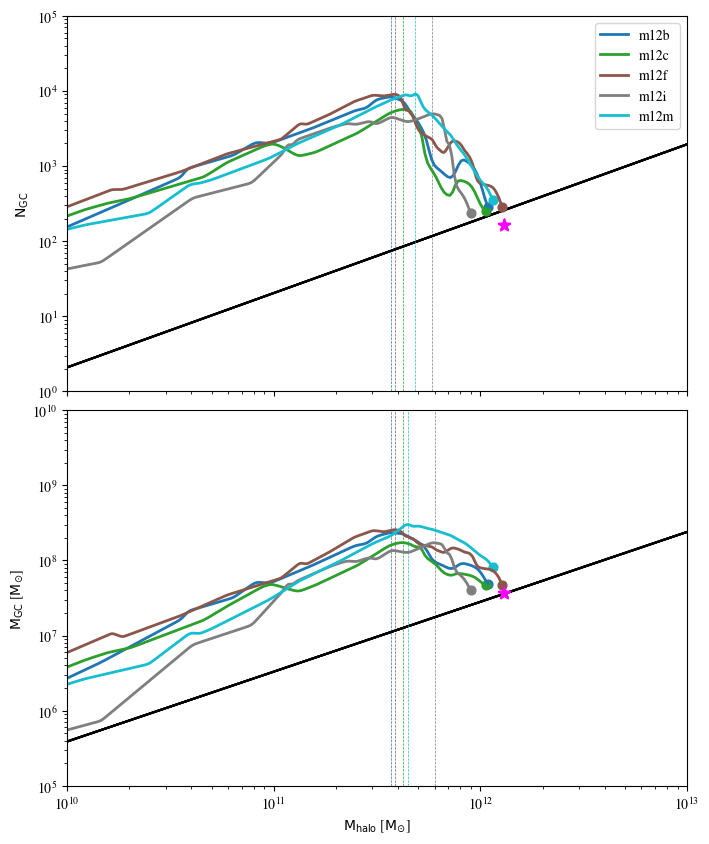

In [17]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 10))
plt.subplots_adjust(hspace=0.05)

tim_z00 = timez0
for sim in sim_lst:
    plot_gc_cnt(axs[0], sim, tim_z00, sim_halt_dict, sim_colors, mw_gcs, plt_to=True, smoothing=True)
    plot_gc_mas(axs[1], sim, tim_z00, sim_halt_dict, sim_colors, mw_gcs, plt_to=True, smoothing=True)

# axs[0].set_xlim(10**8)

axs[1].set_xlabel(r"$\mathrm{M_{halo}}$ [$\mathrm{M_{\odot}}$]")
axs[0].set_xticklabels([])

axs[0].set_ylabel(r"$\mathrm{N_{GC}}$")
axs[1].set_ylabel(r"$\mathrm{M_{GC}}$ [$\mathrm{M_{\odot}}$]")

axs[0].legend()


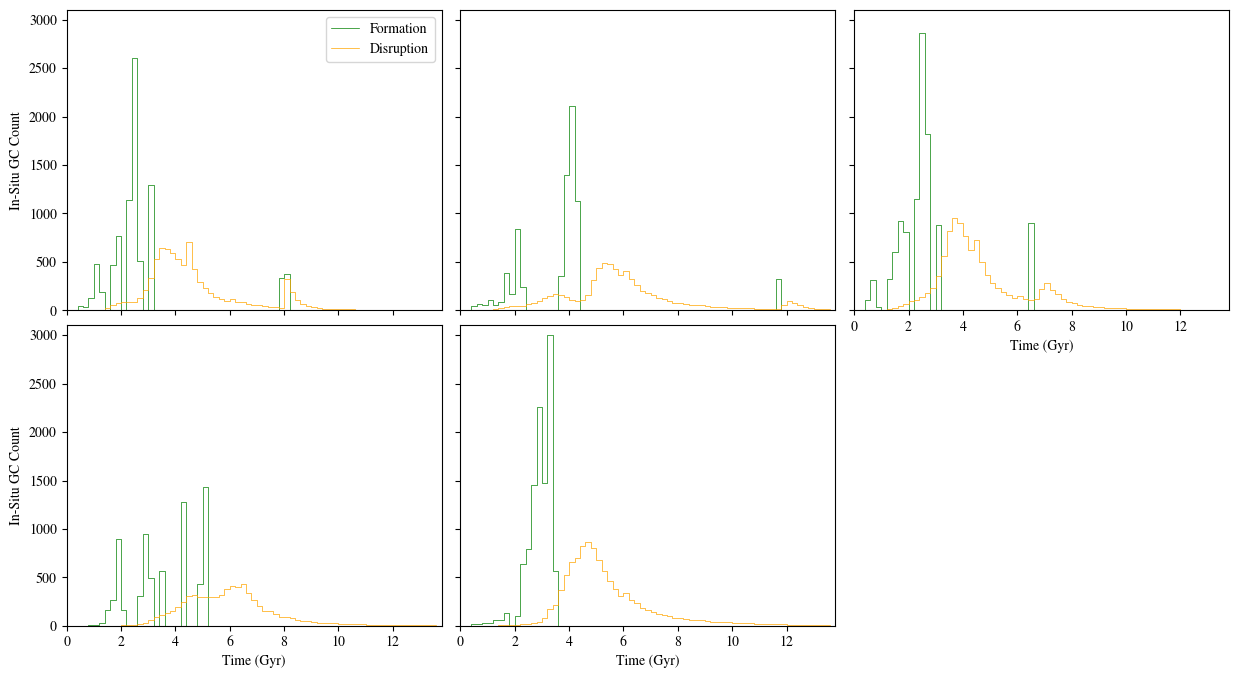

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
plt.subplots_adjust(hspace=0.05, wspace=0.05)

for i, ax in enumerate(axs.flatten()):
    if i == 5:
        ax.axis("off")
        continue

    sim = sim_lst[i]
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    hist_dict = {"sum_for": None, "sum_dis": None, "n": 0}
    bins = np.arange(0, 14, 0.2)

    all_tfors = []
    all_tdiss = []
    for it_id in ghost_data.keys():
        src_dat = ghost_data[it_id]["source"]
        insitu_msk = src_dat["grpid"][()] == 0
        tfors = src_dat["tfor"][insitu_msk]
        tdiss = src_dat["tdis"][insitu_msk]
        all_tfors.append(tfors)
        all_tdiss.append(tdiss)

        hssp_for, _ = np.histogram(tfors, bins=bins)
        hssp_dis, _ = np.histogram(tdiss, bins=bins)

        if hist_dict["sum_for"] is None:
            hist_dict["sum_for"] = hssp_for.astype(float)
            hist_dict["sum_dis"] = hssp_dis.astype(float)
        else:
            hist_dict["sum_for"] += hssp_for
            hist_dict["sum_dis"] += hssp_dis
        hist_dict["n"] += 1

    binsum_for = hist_dict["sum_for"] / hist_dict["n"]
    binsum_dis = hist_dict["sum_dis"] / hist_dict["n"]
    ax.step(bins[:-1], binsum_for, where="post", color="g", lw=0.5, label="Formation")
    ax.step(bins[:-1], binsum_dis, where="post", color="orange", lw=0.5, label="Disruption")

    if i == 0:
        ax.legend(loc="upper right")

    ax.set_xlim(0, 13.8)
    ax.set_ylim(0, 3100)

    if i in [2, 3, 4]:
        ax.set_xlabel("Time (Gyr)")

    if i in [0, 1]:
        ax.set_xticklabels([])

    if i in [0, 3]:
        ax.set_ylabel("In-Situ GC Count")

    if i in [1, 2, 4]:
        ax.set_yticklabels([])

(10, np.float64(15415.119922778964))

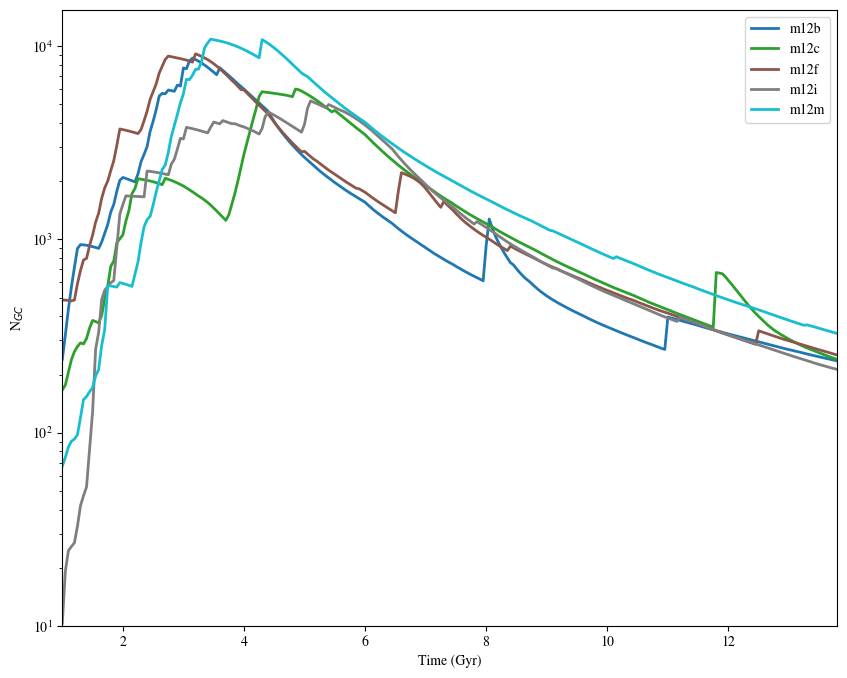

In [59]:
cnt_dict = {sim: {"in": None, "ex": None, "to": None} for sim in sim_lst}
timss = np.arange(1, 14, 0.05)
for sim in sim_lst:
    incnt = []
    excnt = []
    total = []
    for it_id in sim_dict[sim].keys():
        dat = sim_dict[sim][it_id]

        tfor = dat["tfor"]
        tdis = dat["tdis"].copy()
        tdis[tdis == -1] = np.inf
        tacc = dat["tacc"]

        t_snp = dat["t_snp"]
        m_snp = dat["m_snp"]

        incnt_i = []
        excnt_i = []
        total_i = []
        for tim in timss:
            alive = (tfor <= tim) & (tim < tdis)
            inmw = tacc <= tim
            insitu = dat["acc"]

            incnt_i.append(np.sum(alive & inmw & insitu))
            excnt_i.append(np.sum(alive & inmw & ~insitu))
            total_i.append(np.sum(alive & inmw))

        incnt.append(np.asarray(incnt_i))
        excnt.append(np.asarray(excnt_i))
        total.append(np.asarray(total_i))

    incnt_avg = np.mean(incnt, axis=0)
    excnt_avg = np.mean(excnt, axis=0)
    total_avg = np.mean(total, axis=0)

    cnt_dict[sim]["in"] = incnt_avg
    cnt_dict[sim]["ex"] = excnt_avg
    cnt_dict[sim]["to"] = total_avg

plt.figure(figsize=(10, 8))

for i, sim in enumerate(sim_lst):
    plt.plot(tims, cnt_dict[sim]["to"], c=colors[i], lw=2, label=sim)
    # plt.axvline(to_dict[sim]["mas"]["t"], c=colors[i], ls="dashed", zorder=0, lw=1)

plt.yscale("log")
plt.legend(loc="upper right")

plt.xlabel("Time (Gyr)")
plt.ylabel(r"N$_{GC}$")

plt.xlim(1, timez0)
plt.ylim(10**1)

# Individual Sim Plots

In [4]:
sim = "m12m"

tim_z00 = timez0
sim_t_dict = {
    "m12b": {"z = 3.0": 2.21, "z = 2.1": 3.21, "z = 1.0": 5.99, "z = 0.5": 8.73},
    "m12c": {"z = 3.0": 2.21, "z = 1.5": 4.43, "z = 0.8": 6.90, "z = 0.5": 8.73},
    "m12f": {"z = 3.0": 2.21, "z = 2.1": 3.21, "z = 1.0": 5.99, "z = 0.5": 8.73},
    "m12i": {"z = 3.0": 2.21, "z = 1.2": 5.19, "z = 0.8": 6.90, "z = 0.5": 8.73},
    "m12m": {"z = 3.0": 2.21, "z = 1.7": 3.97, "z = 1.0": 5.99, "z = 0.5": 8.73},
}

Text(0, 0.5, 'M$_{GC}$ [M$_{\\odot}$]')

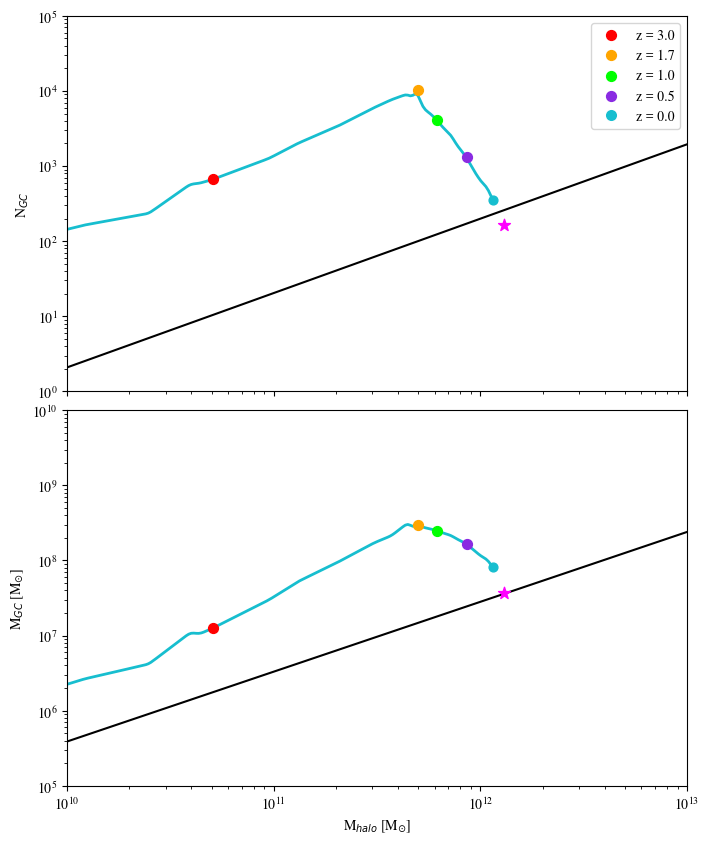

In [46]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 10))
plt.subplots_adjust(hspace=0.05)


# plt_tims = {"z = 10": tim_z10, "z = 5": tim_z10, "z = 2": tim_z02}
# plt_tims = {"z = 2.0": tim_z020, "z = 1.0": tim_z010, "z = 0.5": tim_z005, "z = 0.0": tim_z00}
plot_gc_cnt(axs[0], sim, tim_z00, sim_halt_dict, sim_colors, mw_gcs, smoothing=True, labels=False)
plot_gc_mas(axs[1], sim, tim_z00, sim_halt_dict, sim_colors, mw_gcs, smoothing=True, labels=False)

cols = ["r", "orange", "lime", "blueviolet"]

for i, (lab, tim) in enumerate(sim_t_dict[sim].items()):
    gc_prop_dict = sim_halt_dict[sim]
    #     # Convert JSON-loaded lists → NumPy arrays
    tim_lst = np.asarray(gc_prop_dict["time"])
    mvirs_all = np.asarray(gc_prop_dict["mvir"])
    gccnts_all = np.asarray(gc_prop_dict["cnt_avg"])
    gcmass_all = np.asarray(gc_prop_dict["mas_avg"])

    tmsk = tim_lst <= tim

    mvir_z = mvirs_all[tmsk][-1]
    gccnts_z = gccnts_all[tmsk][-1]
    gcmass_z = gcmass_all[tmsk][-1]

    axs[0].scatter(mvir_z, gccnts_z, c=cols[i], zorder=100, label=lab, s=50)
    axs[1].scatter(mvir_z, gcmass_z, c=cols[i], zorder=100, label=lab, s=50)


extra_handle = Line2D(
    [0],
    [0],
    marker="o",
    color="w",  # no line
    markerfacecolor=sim_colors[sim],  # or any color you want
    markersize=9,
    label="z = 0",
)

# Add to legend
handles, labels = axs[0].get_legend_handles_labels()
handles.append(extra_handle)
labels.append("z = 0.0")

axs[0].legend(handles, labels)

# axs[0].legend()

# axs[0].set_xlim(10**8)

axs[1].set_xlabel(r"M$_{halo}$ [M$_{\odot}$]")
axs[0].set_xticklabels([])

axs[0].set_ylabel(r"N$_{GC}$")
axs[1].set_ylabel(r"M$_{GC}$ [M$_{\odot}$]")

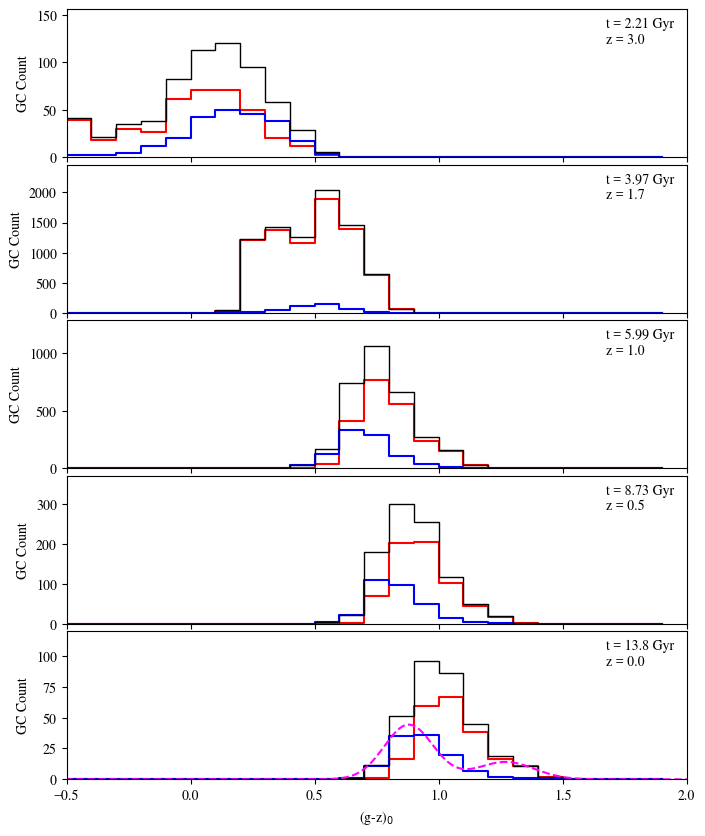

In [47]:
fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(8, 10))
plt.subplots_adjust(hspace=0.05)

bins = np.arange(-0.5, 2.1, 0.1)
i = 0

cols_dict = sim_t_dict[sim]
cols_dict["z = 0.0"] = timez0
for lab, tim in cols_dict.items():
    dif = np.round(np.min(np.abs(tims - tim)), 2)
    print(dif)
    minidx = np.argmin(np.abs(tims - tim))
    mags_hist(axs[i], sim, sim_dict, tims[minidx], tims, bins, bands=["sdss_g", "sdss_z"], origin=True)

    if i == 4:
        axs[i].set_xlabel(r"(g-z)$_{0}$")
    else:
        axs[i].set_xticklabels([])

    text = "t = " + str(np.round(tim, 2)) + " Gyr" + "\n" + lab
    axs[i].text(0.87, 0.85, text, ha="left", va="center", transform=axs[i].transAxes)

    i += 1


# MW Overlay
# Ensure cluster_name is string everywhere
for df in (mw_class, mw_gcs, mw_gcs_cols):
    df["cluster_name"] = df["cluster_name"].astype(str)

# Merge Origin from mw_class with V_abs from mw_gcs
df = mw_class.merge(
    mw_gcs[["cluster_name", "V_abs"]],
    on="cluster_name",
    how="inner",
)

# Merge colour columns from mw_gcs_cols
df = df.merge(
    mw_gcs_cols[
        [
            "cluster_name",
            "JC_V-SDSS_g",
            "JC_V-SDSS_z",
        ]
    ],
    on="cluster_name",
    how="inner",
)

mw_v = df["V_abs"]
mw_g = mw_v - df["JC_V-SDSS_g"]
mw_z = mw_v - df["JC_V-SDSS_z"]

dat = mw_g - mw_z

bins = np.arange(-2, 2.1, 0.1)

fd = gaussian_fitting(dat, bins, K_test=[2], BIC_THRESHOLD=6.0)

model_counts = fd["pdf_total"] * fd["bin_width"] * fd["mean_ngc"]

axs[4].plot(fd["x_plot"], model_counts, c="magenta", ls="--")
# axs[3].set_ylim(0, 80)
# axs[3].set_ylim(0, 80)

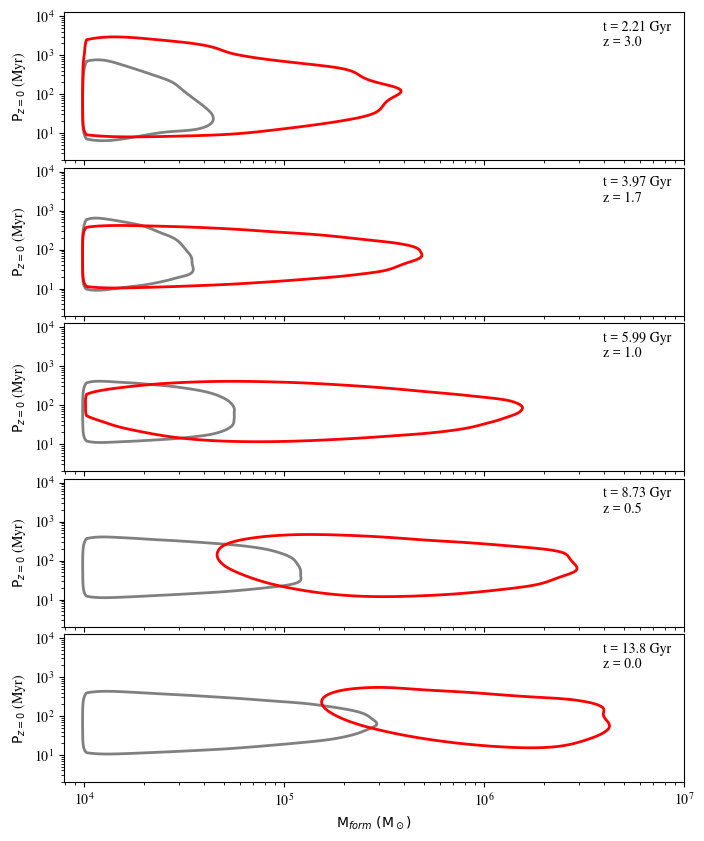

In [48]:
fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(8, 10))
plt.subplots_adjust(hspace=0.05)

bins = np.arange(-2, 2.1, 0.1)
i = 0

cols_dict = sim_t_dict[sim]
cols_dict["z = 0.0"] = timez0
for lab, tim in cols_dict.items():
    # dif = np.round(np.min(np.abs(tims - tim)), 2)
    # print(dif)
    # minidx = np.argmin(np.abs(tims - tim))
    plot_cont_bounding(axs[i], sim, tim, in_msk=True, cont_level=0.95)

    if i == 4:
        pass
    else:
        axs[i].set_xticklabels([])

    text = "t = " + str(np.round(tim, 2)) + " Gyr" + "\n" + lab
    axs[i].text(0.87, 0.85, text, ha="left", va="center", transform=axs[i].transAxes)

    i += 1

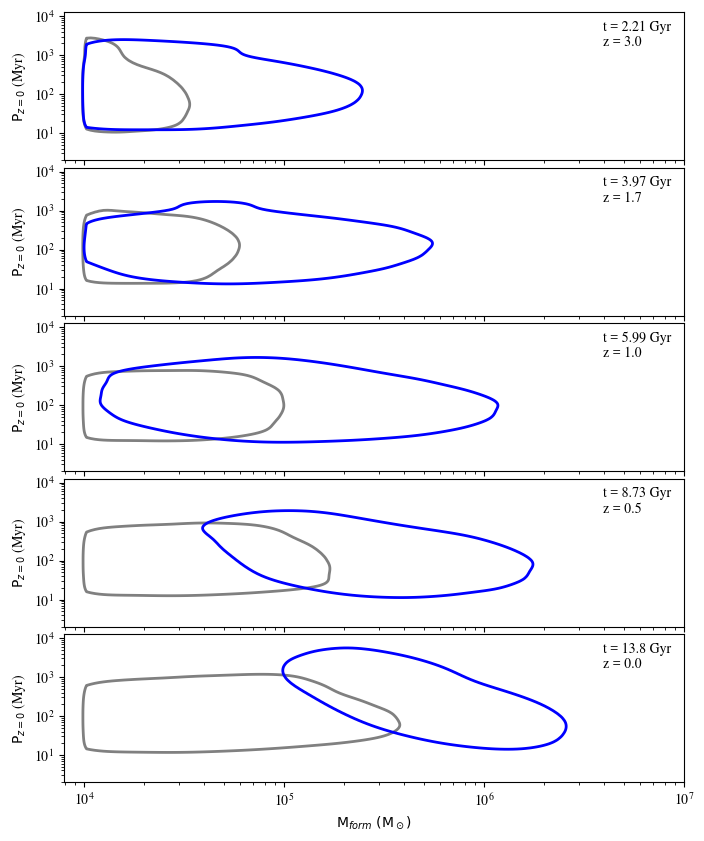

In [49]:
fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(8, 10))
plt.subplots_adjust(hspace=0.05)

bins = np.arange(-2, 2.1, 0.1)
i = 0

cols_dict = sim_t_dict[sim]
cols_dict["z = 0.0"] = timez0
for lab, tim in cols_dict.items():
    # dif = np.round(np.min(np.abs(tims - tim)), 2)
    # print(dif)
    # minidx = np.argmin(np.abs(tims - tim))
    plot_cont_bounding(axs[i], sim, tim, in_msk=False, cont_level=0.95)

    if i == 4:
        pass
    else:
        axs[i].set_xticklabels([])

    text = "t = " + str(np.round(tim, 2)) + " Gyr" + "\n" + lab
    axs[i].text(0.87, 0.85, text, ha="left", va="center", transform=axs[i].transAxes)

    i += 1

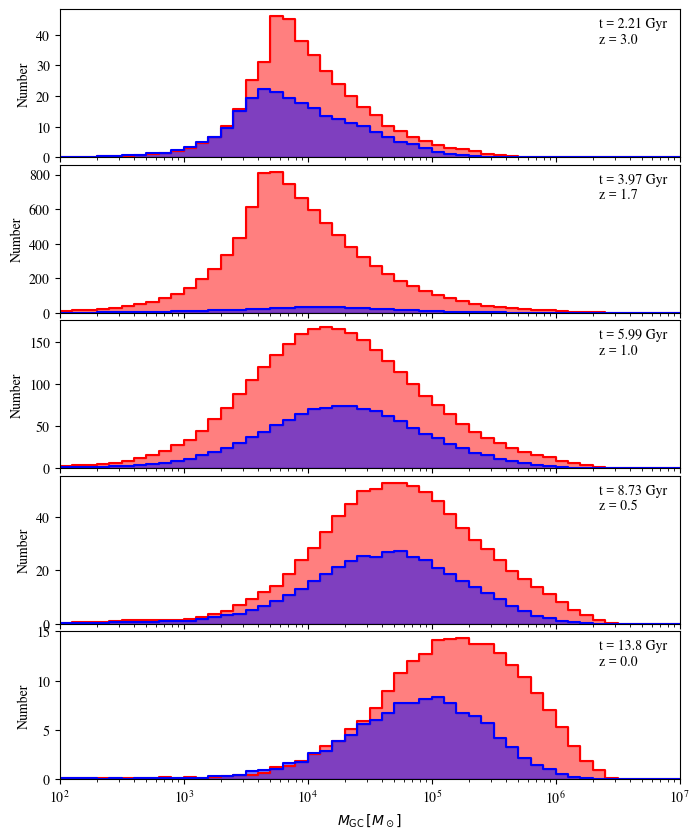

In [50]:
fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(8, 10))
plt.subplots_adjust(hspace=0.05)

bins = np.arange(-2, 2.1, 0.1)
i = 0

cols_dict = sim_t_dict[sim]
cols_dict["z = 0.0"] = timez0
for lab, tim in cols_dict.items():
    # dif = np.round(np.min(np.abs(tims - tim)), 2)
    # print(dif)
    # minidx = np.argmin(np.abs(tims - tim))
    mass_histogram(axs[i], sim, sim_dict, tim, density=False)

    if i == 4:
        pass
    else:
        axs[i].set_xticklabels([])

    text = "t = " + str(np.round(tim, 2)) + " Gyr" + "\n" + lab
    axs[i].text(0.87, 0.85, text, ha="left", va="center", transform=axs[i].transAxes)

    i += 1

Retrieving Snapshot 600..................: 100%|███████████████████████████████████████████████████████████████████████| 1/1 [02:09<00:00, 129.70s/it]


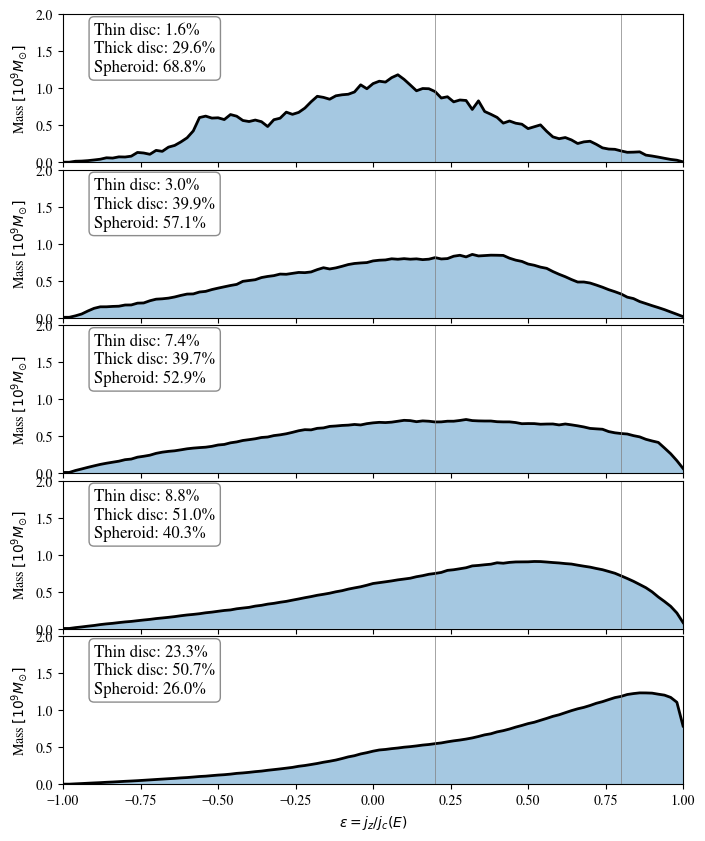

In [7]:
circ_snap_dict = {
    "m12b": [120, 164, 277, 382, 600],
    "m12c": [120, 216, 312, 382, 600],
    "m12f": [120, 165, 277, 382, 600],
    "m12i": [120, 246, 312, 382, 600],
    "m12m": [120, 197, 277, 382, 600],
}

fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(8, 10))
plt.subplots_adjust(hspace=0.05)

halt = gc_utils.get_halo_tree(sim, sim_dir, species="star")
for i, snap in enumerate(circ_snap_dict[sim]):
    plot_circs(axs[i], sim, sim_dir, sim_data, halt, r_lim=5)

    if i == 4:
        pass
    else:
        axs[i].set_xticklabels([])
del halt

In [ ]:
sim_dict[sim]["it001"].keys()

dict_keys(['gcid', 'feh', 'tfor', 'tdis', 'tacc', 'age', 'age_p', 'rz0', 't_tz0', 's_tz0', 'sa_flag', 'acc', 'm_tfo', 'm_tfo_ev', 'm_tz0', 'm_snp', 't_snp', 'mass_interp', 'v', 'sdss_g', 'sdss_z'])

In [31]:
sim_dict[sim]["it001"]["s_tz0"]

array([False, False, False, ..., False, False, False], shape=(10448,))

In [37]:
# AMR
def compute_amr(age, feh, bins):
    inds = np.digitize(age, bins)
    return np.array([np.median(feh[inds == j]) if np.any(inds == j) else np.nan for j in range(1, len(bins))])


bins = np.arange(0, 14.5, 0.5)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

amr_s = []
amr_d = []
for it_id in sim_dict[sim].keys():
    age = sim_dict[sim][it_id]["age"]
    feh = sim_dict[sim][it_id]["feh"]

    imsk = sim_dict[sim][it_id]["acc"]
    smsk = sim_dict[sim][it_id]["s_tz0"]

    amr_s.append(compute_amr(age[imsk & smsk], feh[imsk & smsk], bins))
    amr_d.append(compute_amr(age[imsk & ~smsk], feh[imsk & ~smsk], bins))

amr_s = np.array(amr_s)
amr_d = np.array(amr_d)

In [38]:
compute_amr(age[imsk & smsk], feh[imsk & smsk], bins)

array([   nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan, -0.646, -0.905, -0.938, -1.185, -1.39 , -1.441, -1.546,
       -1.691,    nan,    nan,    nan])

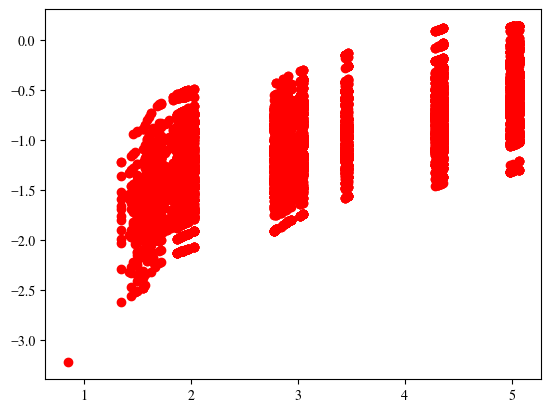

In [44]:
for it_id in sim_dict[sim].keys():
    age = 13.8 - sim_dict[sim][it_id]["age"]
    feh = sim_dict[sim][it_id]["feh"]

    imsk = sim_dict[sim][it_id]["acc"]
    smsk = sim_dict[sim][it_id]["s_tz0"]

    plt.scatter(age[imsk & smsk], feh[imsk & smsk], c="r")
    # plt.scatter(age[imsk & ~smsk], feh[imsk & ~smsk], c="grey")

# MW Plots

[Text(100.0, 0, ''),
 Text(1000.0, 0, ''),
 Text(10000.0, 0, ''),
 Text(100000.0, 0, ''),
 Text(1000000.0, 0, ''),
 Text(10000000.0, 0, ''),
 Text(100000000.0, 0, '')]

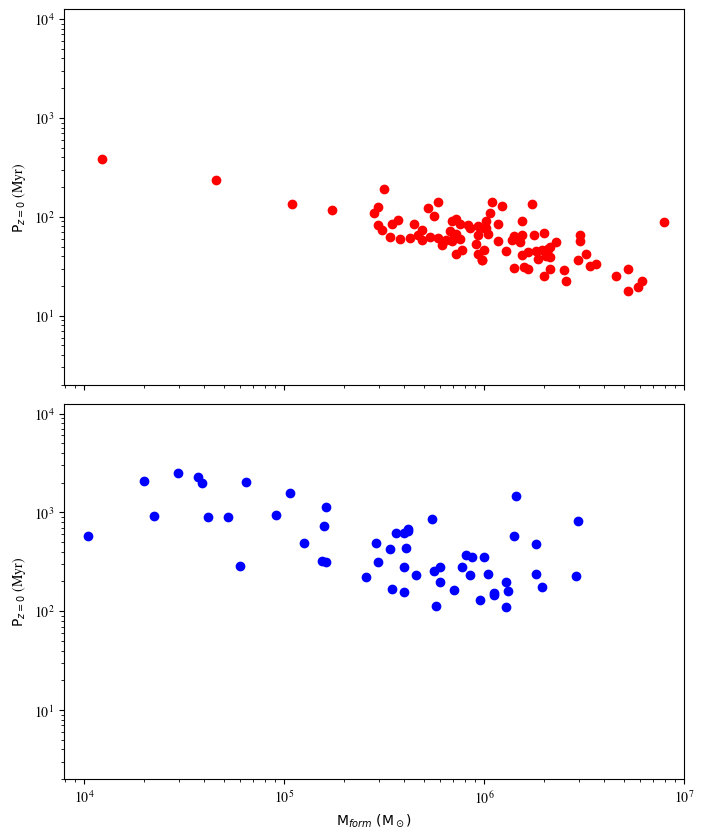

In [86]:
df_orb = mw_gcs.merge(
    mw_class[["cluster_name", "Origin"]],
    on="cluster_name",
    how="inner",
)

torb = df_orb["t_orb"]
mini = 10 ** df_orb["log_mini"]
insitu = df_orb["Origin"] == "in-situ"

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 10))
plt.subplots_adjust(hspace=0.05)

axs[0].scatter(mini[insitu], torb[insitu], c="r")
axs[0].set_xscale("log")
axs[0].set_yscale("log")

axs[1].scatter(mini[~insitu], torb[~insitu], c="b")
axs[1].set_xscale("log")
axs[1].set_yscale("log")

axs[0].set_xlim(10**3.9, 10**7)
axs[0].set_ylim(10**0.3, 10**4.1)

axs[1].set_xlim(10**3.9, 10**7)
axs[1].set_ylim(10**0.3, 10**4.1)

axs[1].set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")

axs[0].set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")
axs[1].set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

axs[0].set_xticklabels([])

In [88]:
df_orb.keys()

Index(['cluster_name', 'ra', 'dec', 'l', 'b', 'r_sun', 'r_sun_err', 'r_gc',
       'rv', 'rv_err', 'pm_ra', 'pm_ra_err', 'pm_dec', 'pm_dec_err',
       'ra_dec_cor', 'x_gc', 'x_gc_err', 'y_gc', 'y_gc_err', 'z_gc',
       'z_gc_err', 'u', 'u_err', 'v', 'v_err', 'w', 'w_err', 'r_per',
       'r_per_err', 'r_apo', 'r_apo_err', 'r_cyl', 'phi_cyl', 'z_cyl',
       'vr_cyl', 'vphi_cyl', 'vz_cyl', 'r_sph', 'theta_sph', 'phi_sph',
       'vr_sph', 'vtheta_sph', 'vphi_sph', 'jr', 'jphi', 'jz', 'jtot', 'lx',
       'ly', 'lz', 'ltot', 'ep', 'ek', 'et', 'inclination', 'circularity',
       'z_max', 'eccentricity', 'V', 'r_hl_pc', 'mass', 'log_mini', 'age_gyr',
       'feh', 'EBV', 'V_abs', 'mass_class', 'class', 'age_assume', 't_orb',
       'Origin'],
      dtype='object')

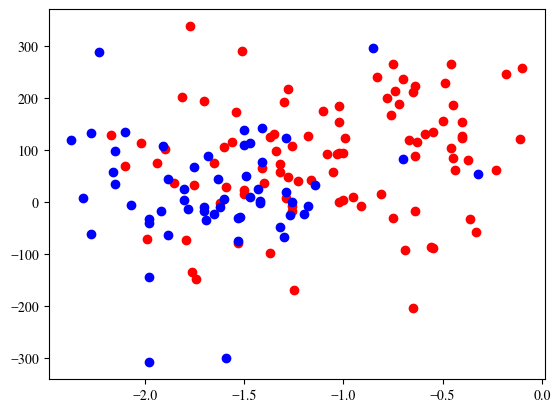

In [97]:
insitu = df_orb["Origin"] == "in-situ"
vphi = df_orb["vphi_cyl"]
feh = df_orb["feh"]

bins = np.arange(-3, 0.5, 0.5)
bin_idx = np.digitize(feh, bins)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
vphi_i = np.full(len(bin_centers), np.nan)
vphi_e = np.full(len(bin_centers), np.nan)

for i in range(1, len(bins)):
    mask = bin_idx == i
    if np.any(mask):
        in_i = insitu[mask]
        vphi_i[i - 1] = np.median(vphi[mask][in_i])
        vphi_e[i - 1] = np.median(vphi[mask][~in_i])

plt.scatter(feh[insitu], vphi[insitu], c="r")
plt.scatter(feh[~insitu], vphi[~insitu], c="b")

# plt.plot(bin_centers, vphi_i, c="r")
# plt.plot(bin_centers, vphi_e, c="b")